**LAB NO 07 : Implementing Forward Propagation**

To implement Forward Propagation in a Neural Network and visualize neuron activations live using TensorFlow.

**Theory**

Forward Propagation

Forward Propagation is the process of passing input data through:

Input Layer

Hidden Layer(s)

Output Layer

Each layer performs:

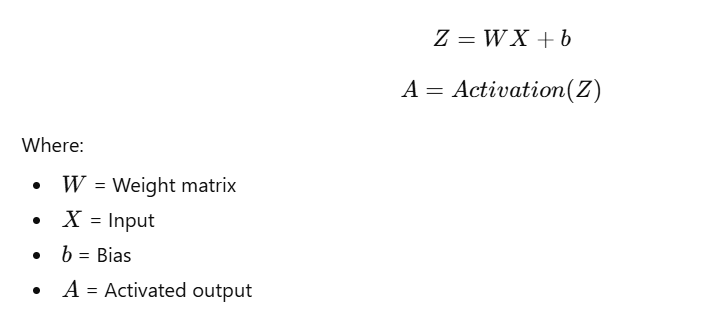

**Activation Functions Used**

ReLU → Hidden Layer

Sigmoid → Output Layer

**Algorithm**

Define input

Initialize weights and biases

Compute hidden layer output

Apply activation function

Compute output layer

Visualize activations

Display final output

TensorFlow Version: 2.19.0


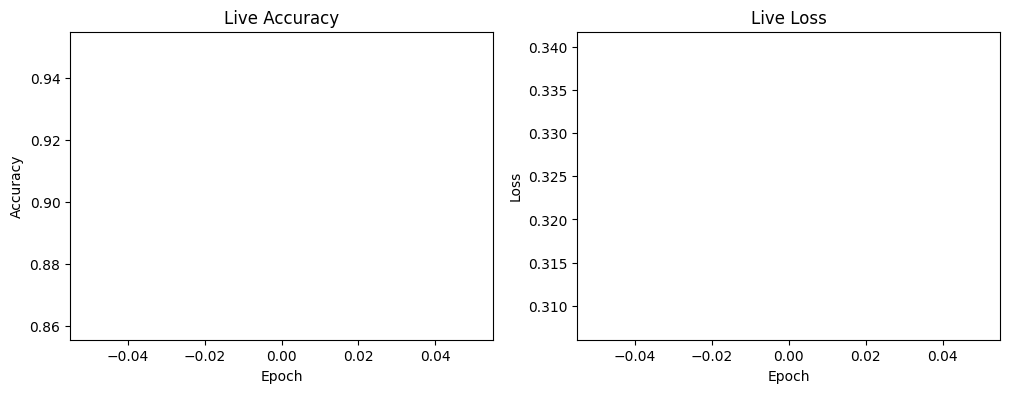

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0764
Final Test Accuracy: 0.9807000160217285
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


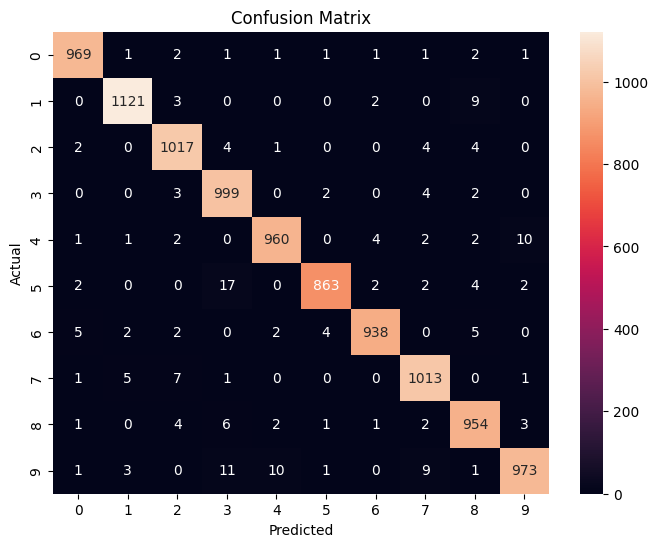

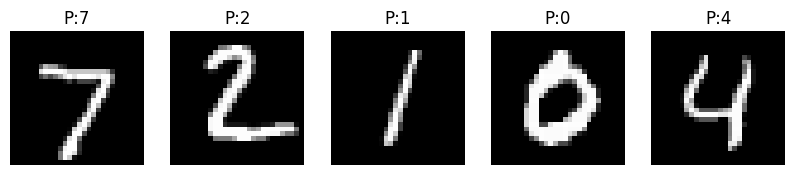

In [5]:
# ==========================================
# ADVANCED LIVE VISUALIZATION LAB (FINAL)
# Deep Neural Network + Live Graphs + Confusion Matrix
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

# Load MNIST Dataset
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Deep Neural Network
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Live Visualization
plt.ion()
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

acc_history = []
loss_history = []

class LiveTraining(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc_history.append(logs['accuracy'])
        loss_history.append(logs['loss'])

        ax1.clear()
        ax1.plot(acc_history)
        ax1.set_title("Live Accuracy")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Accuracy")

        ax2.clear()
        ax2.plot(loss_history)
        ax2.set_title("Live Loss")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")

        plt.pause(0.1)

# Train Model
model.fit(
    X_train, Y_train,
    epochs=5,
    batch_size=128,
    callbacks=[LiveTraining()],
    verbose=0
)

plt.ioff()
plt.show()

# Evaluation
loss, accuracy = model.evaluate(X_test, Y_test)
print("Final Test Accuracy:", accuracy)

# Confusion Matrix
predictions = model.predict(X_test)
pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(Y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Show Sample Predictions
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"P:{pred_classes[i]}")
    plt.axis('off')
plt.show()
